# Illegal Mining Detection — Enhanced Models
**Notebook:** `train_enhanced_models.ipynb`

### What this notebook does
1. Trains **Enhanced Custom CNN** — deeper improved version of your original
2. Trains **EfficientNet-B0** — modern lightweight model (2019)
3. Trains **EfficientNetV2-S** — state-of-the-art model (2021)
4. Compares all **5 models** side by side

### Files saved (nothing else)
```
saved_models/enhanced_cnn.pth
saved_models/efficientnet_b0.pth
saved_models/efficientnetv2_s.pth
saved_models/best_model.pth
```


## Cell 1 — Imports

In [1]:
import os, copy, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device :', device)
if torch.cuda.is_available():
    print('GPU    :', torch.cuda.get_device_name(0))
    print('VRAM   :', round(torch.cuda.get_device_properties(0).total_memory/1024**3,1), 'GB')


Device : cuda
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM   : 8.0 GB


## Cell 2 — Config

In [2]:
DATASET_PATH = r"R:\ai project image\cnn dataset"

BATCH_SIZE  = 32
EPOCHS      = 50
LR_HEAD     = 1e-3
LR_FULL     = 1e-4
PATIENCE    = 10
RANDOM_SEED = 42
NUM_CLASSES = 2

SAVE_DIR = 'saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs('plots', exist_ok=True)
torch.manual_seed(RANDOM_SEED)
print('Config ready.')


Config ready.


## Cell 3 — Transforms

In [3]:
# 64x64 for Enhanced Custom CNN
train_tf_64 = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
val_tf_64 = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# 224x224 for EfficientNet models
train_tf_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
val_tf_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
print('Transforms ready.')


Transforms ready.


## Cell 4 — Dataset Loader Helper

In [4]:
def get_loaders(train_tf, val_tf):
    full = datasets.ImageFolder(root=DATASET_PATH, transform=val_tf)
    total      = len(full)
    train_size = int(0.70 * total)
    val_size   = int(0.15 * total)
    test_size  = total - train_size - val_size

    train_ds, val_ds, test_ds = random_split(
        full, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(RANDOM_SEED)
    )
    # Give training set its own augmented transform
    train_ds.dataset = copy.deepcopy(full)
    train_ds.dataset.transform = train_tf

    tr = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
    vl = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
    te = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
    print(f'Classes: {full.classes}')
    print(f'Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}')
    return tr, vl, te

print('get_loaders defined.')


get_loaders defined.


## Cell 5 — Training & Evaluation Functions

In [5]:
def train_model(model, model_name, train_loader, val_loader,
                num_epochs=EPOCHS, lr=LR_FULL, patience=PATIENCE):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler    = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())
    no_improve   = 0
    save_path    = os.path.join(SAVE_DIR, f'{model_name}.pth')
    history      = {'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}

    print(f'\n{"="*62}')
    print(f'  {model_name}  |  epochs={num_epochs}  lr={lr}')
    print(f'{"="*62}')

    for epoch in range(num_epochs):
        t0 = time.time()

        model.train()
        tl, tc, tt = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward(); optimizer.step()
            tl += loss.item()*imgs.size(0)
            _, p = torch.max(out,1)
            tc += (p==labels).sum().item(); tt += labels.size(0)

        model.eval()
        vl2, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out  = model(imgs)
                loss = criterion(out, labels)
                vl2 += loss.item()*imgs.size(0)
                _, p = torch.max(out,1)
                vc += (p==labels).sum().item(); vt += labels.size(0)

        tr_acc=tc/tt; v_acc=vc/vt
        history['train_loss'].append(tl/tt); history['val_loss'].append(vl2/vt)
        history['train_acc'].append(tr_acc); history['val_acc'].append(v_acc)
        scheduler.step()

        print(f'Epoch [{epoch+1:02d}/{num_epochs}]  '
              f'Train: {tr_acc:.4f}  Val: {v_acc:.4f}  {time.time()-t0:.1f}s')

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_weights = copy.deepcopy(model.state_dict())
            no_improve   = 0
            torch.save(best_weights, save_path)
            print(f'  >> Saved best  val_acc={best_val_acc:.4f}')
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stopping at epoch {epoch+1}')
                break

    model.load_state_dict(best_weights)
    print(f'Done. Best val_acc={best_val_acc:.4f} -> {save_path}')
    return model, history, best_val_acc


def warmup_head(model, train_loader, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=LR_HEAD
    )
    print(f'  Warmup {epochs} epochs (head only)...')
    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out=model(imgs); loss=criterion(out,labels)
            loss.backward(); optimizer.step()
            _, p=torch.max(out,1)
            correct+=(p==labels).sum().item(); total+=labels.size(0)
        print(f'    Warmup {epoch+1}/{epochs}  acc={correct/total:.4f}')
    for param in model.parameters():
        param.requires_grad = True
    print('  All layers unfrozen.')


def evaluate_model(model, model_name, test_loader):
    model.eval()
    preds_all, labels_all, probs_all = [], [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs=imgs.to(device)
            out=model(imgs)
            prob=torch.softmax(out,dim=1)[:,1]
            _,p=torch.max(out,1)
            preds_all.extend(p.cpu().numpy())
            labels_all.extend(labels.numpy())
            probs_all.extend(prob.cpu().numpy())

    preds_all=np.array(preds_all); labels_all=np.array(labels_all); probs_all=np.array(probs_all)
    acc = (preds_all==labels_all).mean()
    auc = roc_auc_score(labels_all, probs_all)
    report = classification_report(labels_all, preds_all,
                                   target_names=['Non-Mining','Mining'])
    cm = confusion_matrix(labels_all, preds_all)

    print(f'\n{"="*55}\n  {model_name}\n{"="*55}')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  AUC-ROC  : {auc:.4f}')
    print(f'\n{report}')
    print(f'Confusion Matrix:\n{cm}')

    return {'name':model_name,'accuracy':acc,'auc':auc,'cm':cm,
            'preds':preds_all,'labels':labels_all,'probs':probs_all}


def plot_history(history, model_name):
    fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,4))
    ax1.plot(history['train_acc'], label='Train',color='steelblue')
    ax1.plot(history['val_acc'],   label='Val',  color='darkorange')
    ax1.set_title(f'{model_name} — Accuracy'); ax1.legend(); ax1.grid(True)
    ax2.plot(history['train_loss'],label='Train',color='steelblue')
    ax2.plot(history['val_loss'],  label='Val',  color='darkorange')
    ax2.set_title(f'{model_name} — Loss'); ax2.legend(); ax2.grid(True)
    plt.suptitle(model_name,fontsize=13); plt.tight_layout()
    fname=f'plots/{model_name.lower().replace(" ","_").replace("-","_")}_training.png'
    plt.savefig(fname,dpi=150,bbox_inches='tight'); plt.show()
    print(f'Saved: {fname}')


def plot_confusion(result):
    plt.figure(figsize=(5,4))
    sns.heatmap(result['cm'],annot=True,fmt='d',cmap='Blues',
                xticklabels=['Non-Mining','Mining'],yticklabels=['Non-Mining','Mining'])
    plt.title(f'Confusion Matrix — {result["name"]}')
    plt.ylabel('True'); plt.xlabel('Predicted'); plt.tight_layout()
    fname=f'plots/{result["name"].lower().replace(" ","_").replace("-","_")}_cm.png'
    plt.savefig(fname,dpi=150,bbox_inches='tight'); plt.show()
    print(f'Saved: {fname}')

print('All functions defined.')


All functions defined.


## Cell 6 — Enhanced Custom CNN Architecture

### Improvements over original:
| | Original CNN | Enhanced CNN |
|--|--|--|
| Conv blocks | 3 | 4 |
| Channels | 32→64→128 | 32→64→128→256 |
| Convs per block | 1 | 2 (doubles receptive field) |
| Pooling | MaxPool only | MaxPool + GlobalAvgPool |
| Classifier head | 8192→128→1 (BCE) | 256→128→64→2 (CE) |
| Dropout | 0.5 (one layer) | 0.4 + 0.3 (two layers) |
| Optimizer | Adam | AdamW + CosineAnnealing |


In [6]:
class EnhancedCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)   # 64 -> 32
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)   # 32 -> 16
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)   # 16 -> 8
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)   # 8 -> 4
        )
        self.gap = nn.AdaptiveAvgPool2d((1, 1))   # 4x4 -> 1x1, output = 256

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(128,  64), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear( 64, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

enhanced_cnn = EnhancedCNN(num_classes=NUM_CLASSES).to(device)
total = sum(p.numel() for p in enhanced_cnn.parameters())
print(f'Enhanced CNN — Total params: {total:,}')


Enhanced CNN — Total params: 1,215,458


## Cell 7 — Train Enhanced CNN

In [7]:
train_loader_64, val_loader_64, test_loader_64 = get_loaders(train_tf_64, val_tf_64)

enhanced_cnn, hist_ecnn, best_ecnn = train_model(
    enhanced_cnn, 'enhanced_cnn',
    train_loader_64, val_loader_64,
    num_epochs=EPOCHS, lr=1e-3, patience=PATIENCE
)


Classes: ['mining', 'non mining']
Train: 2068  Val: 443  Test: 444

  enhanced_cnn  |  epochs=50  lr=0.001
Epoch [01/50]  Train: 0.8380  Val: 0.8962  7.9s
  >> Saved best  val_acc=0.8962
Epoch [02/50]  Train: 0.8893  Val: 0.8962  7.4s
Epoch [03/50]  Train: 0.8835  Val: 0.8871  6.8s
Epoch [04/50]  Train: 0.8830  Val: 0.8668  7.7s
Epoch [05/50]  Train: 0.9130  Val: 0.8962  6.9s
Epoch [06/50]  Train: 0.9043  Val: 0.8849  7.7s
Epoch [07/50]  Train: 0.8970  Val: 0.9233  6.7s
  >> Saved best  val_acc=0.9233
Epoch [08/50]  Train: 0.9004  Val: 0.9187  7.6s
Epoch [09/50]  Train: 0.9018  Val: 0.9120  6.7s
Epoch [10/50]  Train: 0.9033  Val: 0.9233  7.3s
Epoch [11/50]  Train: 0.9120  Val: 0.9210  6.9s
Epoch [12/50]  Train: 0.9091  Val: 0.9120  7.5s
Epoch [13/50]  Train: 0.9096  Val: 0.9074  6.8s
Epoch [14/50]  Train: 0.9086  Val: 0.9097  7.4s
Epoch [15/50]  Train: 0.9057  Val: 0.8691  6.8s
Epoch [16/50]  Train: 0.9076  Val: 0.9165  7.4s
Epoch [17/50]  Train: 0.9115  Val: 0.9120  6.8s
  Early stopp

## Cell 8 — Evaluate Enhanced CNN


  Enhanced CNN
  Accuracy : 0.9257
  AUC-ROC  : 0.9785

              precision    recall  f1-score   support

  Non-Mining       0.95      0.85      0.89       165
      Mining       0.92      0.97      0.94       279

    accuracy                           0.93       444
   macro avg       0.93      0.91      0.92       444
weighted avg       0.93      0.93      0.92       444

Confusion Matrix:
[[140  25]
 [  8 271]]


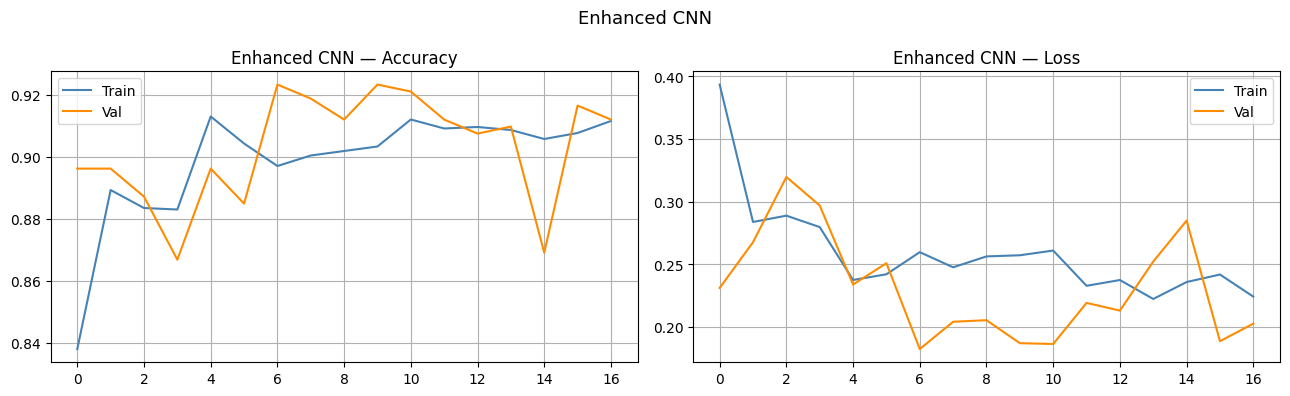

Saved: plots/enhanced_cnn_training.png


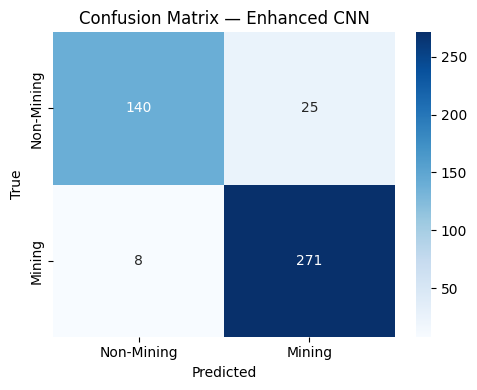

Saved: plots/enhanced_cnn_cm.png


In [8]:
enhanced_cnn.load_state_dict(torch.load('saved_models/enhanced_cnn.pth', map_location=device))
ecnn_results = evaluate_model(enhanced_cnn, 'Enhanced CNN', test_loader_64)
plot_history(hist_ecnn, 'Enhanced CNN')
plot_confusion(ecnn_results)


## Cell 9 — Build EfficientNet-B0
5.3M parameters. Lightweight but strong. Very popular in recent remote sensing papers.


In [9]:
def build_efficientnet_b0():
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    in_f = model.classifier[1].in_features   # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_f, 256), nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, NUM_CLASSES)
    )
    return model.to(device)

effb0 = build_efficientnet_b0()
trainable = sum(p.numel() for p in effb0.parameters() if p.requires_grad)
total     = sum(p.numel() for p in effb0.parameters())
print(f'EfficientNet-B0  |  Total: {total:,}  |  Trainable (head): {trainable:,}')


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Rohit Bansal/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100.0%


EfficientNet-B0  |  Total: 4,335,998  |  Trainable (head): 328,450


## Cell 10 — Train EfficientNet-B0

In [10]:
train_loader_224, val_loader_224, test_loader_224 = get_loaders(train_tf_224, val_tf_224)

# Warmup head (no checkpoint saved during warmup)
warmup_head(effb0, train_loader_224, epochs=10)

# Full fine-tune (only this checkpoint saved)
effb0, hist_b0, best_b0 = train_model(
    effb0, 'efficientnet_b0',
    train_loader_224, val_loader_224,
    num_epochs=EPOCHS, lr=LR_FULL, patience=PATIENCE
)


Classes: ['mining', 'non mining']
Train: 2068  Val: 443  Test: 444
  Warmup 10 epochs (head only)...
    Warmup 1/10  acc=0.8341
    Warmup 2/10  acc=0.8665
    Warmup 3/10  acc=0.8757
    Warmup 4/10  acc=0.8694
    Warmup 5/10  acc=0.8820
    Warmup 6/10  acc=0.8864
    Warmup 7/10  acc=0.8830
    Warmup 8/10  acc=0.8873
    Warmup 9/10  acc=0.8907
    Warmup 10/10  acc=0.8902
  All layers unfrozen.

  efficientnet_b0  |  epochs=50  lr=0.0001
Epoch [01/50]  Train: 0.8849  Val: 0.9007  21.1s
  >> Saved best  val_acc=0.9007
Epoch [02/50]  Train: 0.9207  Val: 0.9120  20.1s
  >> Saved best  val_acc=0.9120
Epoch [03/50]  Train: 0.9231  Val: 0.9233  19.8s
  >> Saved best  val_acc=0.9233
Epoch [04/50]  Train: 0.9279  Val: 0.9278  19.9s
  >> Saved best  val_acc=0.9278
Epoch [05/50]  Train: 0.9299  Val: 0.9255  19.7s
Epoch [06/50]  Train: 0.9284  Val: 0.9210  19.1s
Epoch [07/50]  Train: 0.9429  Val: 0.9233  19.4s
Epoch [08/50]  Train: 0.9313  Val: 0.9165  19.4s
Epoch [09/50]  Train: 0.9478  V

## Cell 11 — Evaluate EfficientNet-B0


  EfficientNet-B0
  Accuracy : 0.9257
  AUC-ROC  : 0.9787

              precision    recall  f1-score   support

  Non-Mining       0.91      0.89      0.90       165
      Mining       0.94      0.95      0.94       279

    accuracy                           0.93       444
   macro avg       0.92      0.92      0.92       444
weighted avg       0.93      0.93      0.93       444

Confusion Matrix:
[[147  18]
 [ 15 264]]


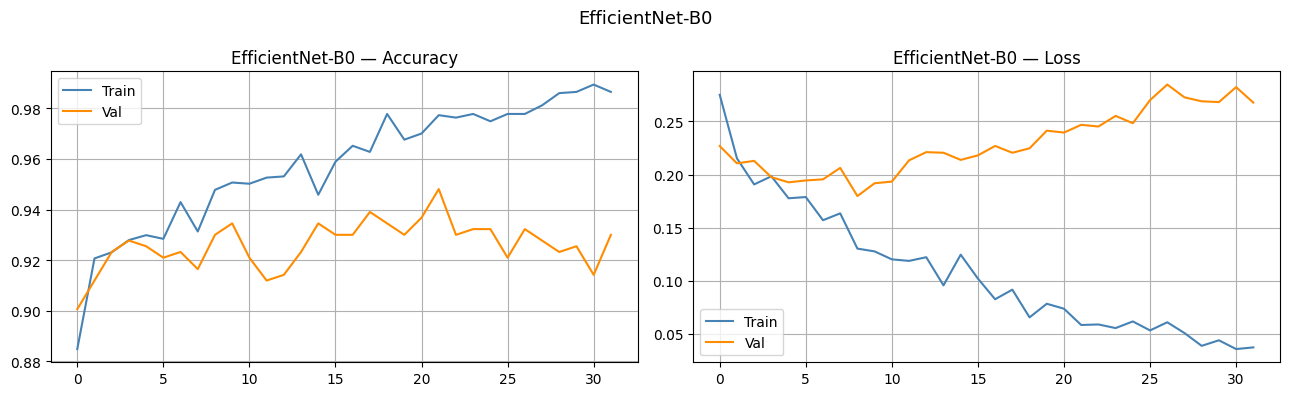

Saved: plots/efficientnet_b0_training.png


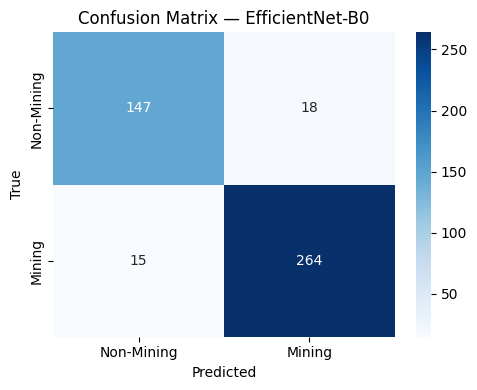

Saved: plots/efficientnet_b0_cm.png


In [11]:
effb0.load_state_dict(torch.load('saved_models/efficientnet_b0.pth', map_location=device))
effb0_results = evaluate_model(effb0, 'EfficientNet-B0', test_loader_224)
plot_history(hist_b0, 'EfficientNet-B0')
plot_confusion(effb0_results)


## Cell 12 — Build EfficientNetV2-S
21.5M parameters. Released 2021. Faster training than original EfficientNet, better accuracy.
State-of-the-art for image classification.


In [12]:
def build_efficientnetv2_s():
    model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    in_f = model.classifier[1].in_features   # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_f, 256), nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, NUM_CLASSES)
    )
    return model.to(device)

effv2s = build_efficientnetv2_s()
trainable = sum(p.numel() for p in effv2s.parameters() if p.requires_grad)
total     = sum(p.numel() for p in effv2s.parameters())
print(f'EfficientNetV2-S  |  Total: {total:,}  |  Trainable (head): {trainable:,}')


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to C:\Users\Rohit Bansal/.cache\torch\hub\checkpoints\efficientnet_v2_s-dd5fe13b.pth
100.0%


EfficientNetV2-S  |  Total: 20,505,938  |  Trainable (head): 328,450


## Cell 13 — Train EfficientNetV2-S

In [14]:
# Reuse 224x224 loaders
warmup_head(effv2s, train_loader_224, epochs=10)

effv2s, hist_v2s, best_v2s = train_model(
    effv2s, 'efficientnetv2_s',
    train_loader_224, val_loader_224,
    num_epochs=EPOCHS, lr=LR_FULL, patience=PATIENCE
)


  Warmup 10 epochs (head only)...
    Warmup 1/10  acc=0.8380
    Warmup 2/10  acc=0.8428
    Warmup 3/10  acc=0.8380
    Warmup 4/10  acc=0.8308
    Warmup 5/10  acc=0.8390
    Warmup 6/10  acc=0.8399
    Warmup 7/10  acc=0.8462
    Warmup 8/10  acc=0.8457
    Warmup 9/10  acc=0.8341
    Warmup 10/10  acc=0.8462
  All layers unfrozen.

  efficientnetv2_s  |  epochs=50  lr=0.0001
Epoch [01/50]  Train: 0.8694  Val: 0.9029  29.0s
  >> Saved best  val_acc=0.9029
Epoch [02/50]  Train: 0.9018  Val: 0.8984  31.1s
Epoch [03/50]  Train: 0.9250  Val: 0.8781  31.5s
Epoch [04/50]  Train: 0.9207  Val: 0.9233  31.5s
  >> Saved best  val_acc=0.9233
Epoch [05/50]  Train: 0.9444  Val: 0.9233  31.4s
Epoch [06/50]  Train: 0.9362  Val: 0.9142  30.5s
Epoch [07/50]  Train: 0.9400  Val: 0.9165  30.1s
Epoch [08/50]  Train: 0.9536  Val: 0.9210  30.3s
Epoch [09/50]  Train: 0.9565  Val: 0.9187  30.3s
Epoch [10/50]  Train: 0.9560  Val: 0.9120  30.4s
Epoch [11/50]  Train: 0.9666  Val: 0.9187  29.0s
Epoch [12/50] 

## Cell 14 — Evaluate EfficientNetV2-S


  EfficientNetV2-S
  Accuracy : 0.9279
  AUC-ROC  : 0.9808

              precision    recall  f1-score   support

  Non-Mining       0.95      0.85      0.90       165
      Mining       0.92      0.97      0.94       279

    accuracy                           0.93       444
   macro avg       0.93      0.91      0.92       444
weighted avg       0.93      0.93      0.93       444

Confusion Matrix:
[[140  25]
 [  7 272]]


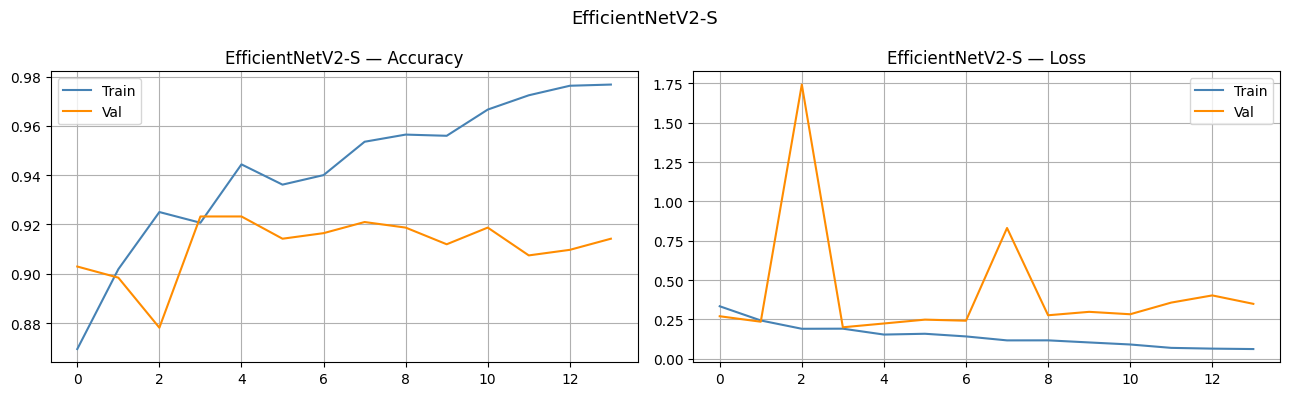

Saved: plots/efficientnetv2_s_training.png


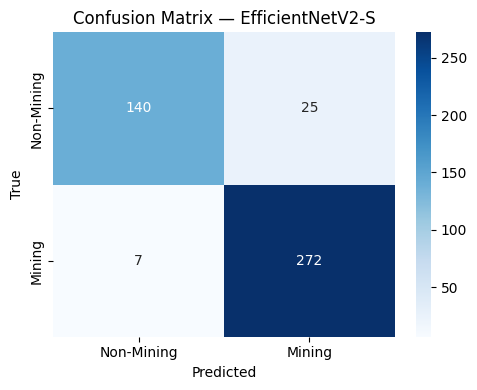

Saved: plots/efficientnetv2_s_cm.png


In [15]:
effv2s.load_state_dict(torch.load('saved_models/efficientnetv2_s.pth', map_location=device))
effv2s_results = evaluate_model(effv2s, 'EfficientNetV2-S', test_loader_224)
plot_history(hist_v2s, 'EfficientNetV2-S')
plot_confusion(effv2s_results)


## Cell 15 — Paste Earlier Results

In [16]:
# ── Update these with your actual numbers from earlier notebooks ──────────
original_cnn = {'name':'Custom CNN (original)', 'accuracy':0.9167, 'auc':0.9741, 'probs':None, 'labels':None}
resnet18     = {'name':'ResNet-18',              'accuracy':0.9189, 'auc':0.9738, 'probs':None, 'labels':None}
mobilenetv2  = {'name':'MobileNetV2',            'accuracy':0.9212, 'auc':0.9734, 'probs':None, 'labels':None}

print('Earlier results:')
for r in [original_cnn, resnet18, mobilenetv2]:
    print(f'  {r["name"]:<25}  acc={r["accuracy"]:.4f}  auc={r["auc"]:.4f}')


Earlier results:
  Custom CNN (original)      acc=0.9167  auc=0.9741
  ResNet-18                  acc=0.9189  auc=0.9738
  MobileNetV2                acc=0.9212  auc=0.9734


## Cell 16 — All 5 Models Comparison


  ALL MODELS — FINAL COMPARISON
  Model                          Accuracy    AUC-ROC
  --------------------------------------------------
  Custom CNN (original)            0.9167     0.9741
  ResNet-18                        0.9189     0.9738
  MobileNetV2                      0.9212     0.9734
  Enhanced CNN                     0.9257     0.9785
  EfficientNet-B0                  0.9257     0.9787
  EfficientNetV2-S                 0.9279     0.9808  << BEST


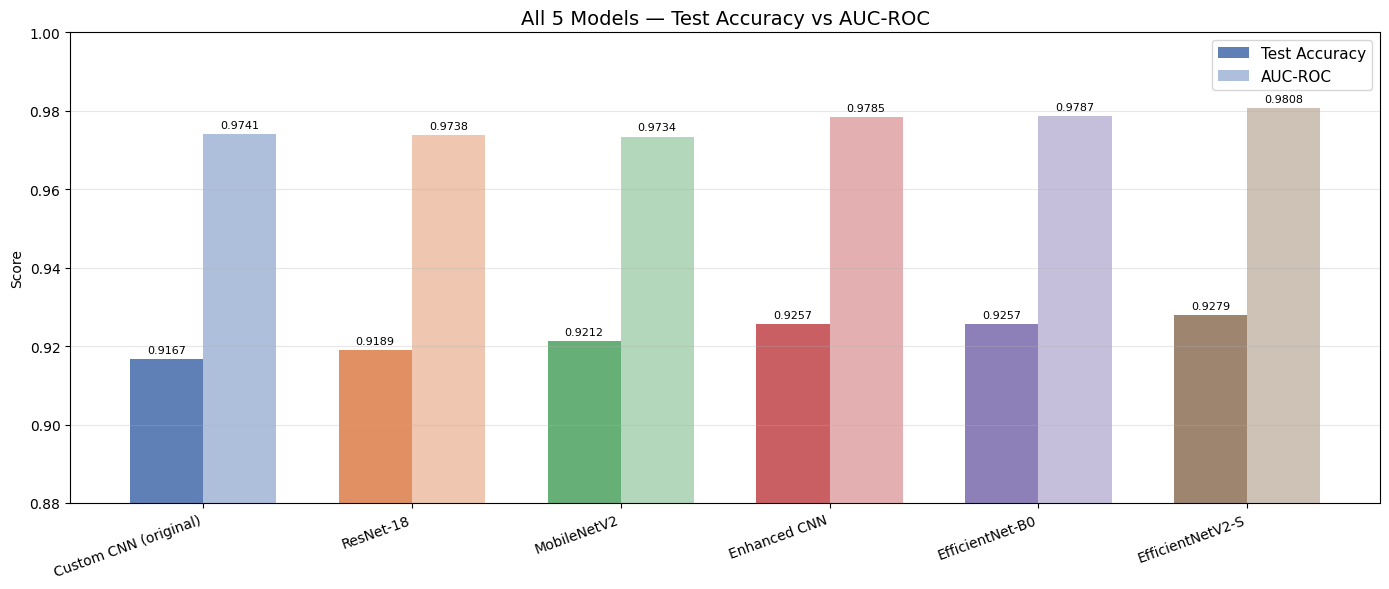

Saved: plots/all5_model_comparison.png


In [17]:
all_results = [original_cnn, resnet18, mobilenetv2,
               ecnn_results, effb0_results, effv2s_results]

print(f'\n{"="*60}')
print(f'  ALL MODELS — FINAL COMPARISON')
print(f'{"="*60}')
print(f'  {"Model":<28} {"Accuracy":>10} {"AUC-ROC":>10}')
print(f'  {"-"*50}')
best_acc = max(r['accuracy'] for r in all_results)
for r in all_results:
    tag = '  << BEST' if r['accuracy'] == best_acc else ''
    print(f'  {r["name"]:<28} {r["accuracy"]:>10.4f} {r["auc"]:>10.4f}{tag}')
print(f'{"="*60}')

# Bar chart
names = [r['name'] for r in all_results]
accs  = [r['accuracy'] for r in all_results]
aucs  = [r['auc'] for r in all_results]
cols  = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

x = np.arange(len(names)); w = 0.35
fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x-w/2, accs, w, label='Test Accuracy', color=cols, alpha=0.9)
b2 = ax.bar(x+w/2, aucs, w, label='AUC-ROC',       color=cols, alpha=0.45)
ax.set_title('All 5 Models — Test Accuracy vs AUC-ROC', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0.88, 1.0); ax.set_ylabel('Score')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
ax.bar_label(b1, fmt='%.4f', padding=3, fontsize=8)
ax.bar_label(b2, fmt='%.4f', padding=3, fontsize=8)
plt.tight_layout()
plt.savefig('plots/all5_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/all5_model_comparison.png')


## Cell 17 — ROC Curves

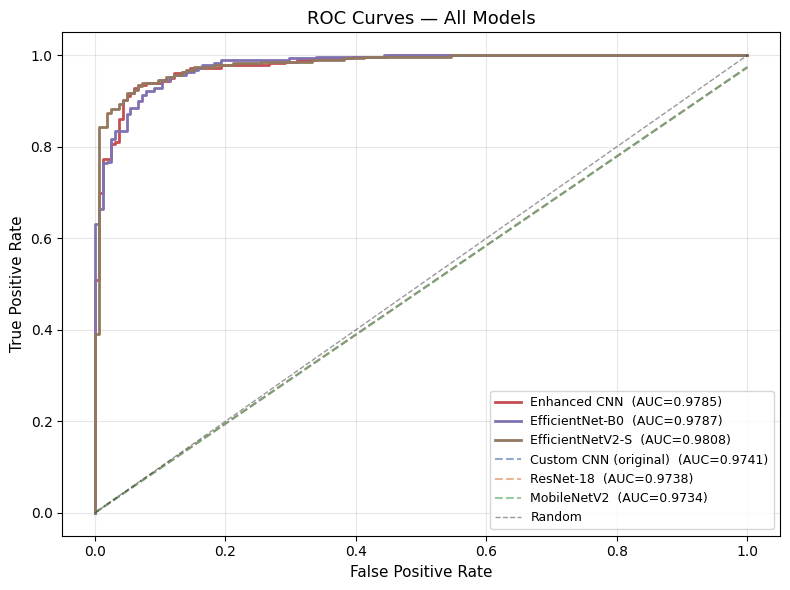

Saved: plots/all5_roc_curves.png


In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
line_styles = ['-','-','-']
for result, color in zip([ecnn_results, effb0_results, effv2s_results],
                          ['#C44E52','#8172B2','#937860']):
    fpr, tpr, _ = roc_curve(result['labels'], result['probs'])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{result["name"]}  (AUC={result["auc"]:.4f})')

for r, color in zip([original_cnn, resnet18, mobilenetv2],
                    ['#4C72B0','#DD8452','#55A868']):
    ax.plot([0,1],[0,r['auc']], color=color, lw=1.5, linestyle='--', alpha=0.6,
            label=f'{r["name"]}  (AUC={r["auc"]:.4f})')

ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.4,label='Random')
ax.set_xlabel('False Positive Rate',fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — All Models', fontsize=13)
ax.legend(loc='lower right', fontsize=9); ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig('plots/all5_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/all5_roc_curves.png')


## Cell 18 — Save Best Model

In [19]:
import shutil

new_only = [ecnn_results, effb0_results, effv2s_results]
best = max(new_only, key=lambda r: r['accuracy'])

src_map = {
    'Enhanced CNN'    : 'saved_models/enhanced_cnn.pth',
    'EfficientNet-B0' : 'saved_models/efficientnet_b0.pth',
    'EfficientNetV2-S': 'saved_models/efficientnetv2_s.pth',
}
shutil.copy(src_map[best['name']], 'saved_models/best_model.pth')

print(f'Best new model : {best["name"]}')
print(f'Accuracy       : {best["accuracy"]:.4f}')
print(f'AUC-ROC        : {best["auc"]:.4f}')
print(f'Saved to       : saved_models/best_model.pth')


Best new model : EfficientNetV2-S
Accuracy       : 0.9279
AUC-ROC        : 0.9808
Saved to       : saved_models/best_model.pth


## Cell 19 — Summary

In [20]:
print('='*55)
print('  DONE')
print('='*55)
new_files = ['enhanced_cnn.pth','efficientnet_b0.pth',
             'efficientnetv2_s.pth','best_model.pth']
print('\nNew files in saved_models/:')
for f in new_files:
    p = f'saved_models/{f}'
    if os.path.exists(p):
        print(f'  {f:<35} {os.path.getsize(p)/1024/1024:.1f} MB')

print('\nPlots saved in plots/:')
for f in sorted(os.listdir('plots')):
    print(f'  {f}')

print('\nNext step -> inference_visualizer.ipynb')


  DONE

New files in saved_models/:
  enhanced_cnn.pth                    4.7 MB
  efficientnet_b0.pth                 16.8 MB
  efficientnetv2_s.pth                79.1 MB
  best_model.pth                      79.1 MB

Plots saved in plots/:
  all5_model_comparison.png
  all5_roc_curves.png
  custom_cnn_confusion_matrix.png
  custom_cnn_training.png
  efficientnet_b0_cm.png
  efficientnet_b0_training.png
  efficientnetv2_s_cm.png
  efficientnetv2_s_training.png
  enhanced_cnn_cm.png
  enhanced_cnn_training.png
  mobilenetv2_cm.png
  mobilenetv2_training.png
  model_comparison.png
  resnet_18_cm.png
  resnet_18_training.png
  roc_curves.png

Next step -> inference_visualizer.ipynb
